In [1]:
import pandas as pd
import sqlite3

# Connect to our SQLite database and load the data
conn = sqlite3.connect("../Data/churn.db")
df = pd.read_sql_query("SELECT * FROM customers", conn)
conn.close()

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# Investigate TotalCharges column
print("Sample of TotalCharges values:")
print(df['TotalCharges'].head(10))

# Try converting to numeric - this will show us which rows fail
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Find rows where conversion failed (these become NaN)
problem_rows = df[df['TotalCharges_numeric'].isna()]
print(f"\nNumber of problematic rows: {len(problem_rows)}")
print("\nThese rows look like:")
problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Sample of TotalCharges values:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

Number of problematic rows: 11

These rows look like:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [5]:
# Fix: Replace blank TotalCharges with 0 for tenure=0 customers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop the temporary helper column we made earlier
df = df.drop(columns=['TotalCharges_numeric'])

# Verify the fix worked
print("New dtype:", df['TotalCharges'].dtype)
print("Any missing values left?", df['TotalCharges'].isna().sum())
print("\nConfirm the 11 rows are now 0:")
print(df[df['tenure'] == 0][['customerID', 'tenure', 'TotalCharges']])

New dtype: float64
Any missing values left? 0

Confirm the 11 rows are now 0:
      customerID  tenure  TotalCharges
488   4472-LVYGI       0           0.0
753   3115-CZMZD       0           0.0
936   5709-LVOEQ       0           0.0
1082  4367-NUYAO       0           0.0
1340  1371-DWPAZ       0           0.0
3331  7644-OMVMY       0           0.0
3826  3213-VVOLG       0           0.0
4380  2520-SGTTA       0           0.0
5218  2923-ARZLG       0           0.0
6670  4075-WKNIU       0           0.0
6754  2775-SEFEE       0           0.0


In [6]:
# Check for duplicate customer IDs
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

# Check for any other missing values across all columns
print("\nMissing values per column:")
print(df.isnull().sum().sum(), "total missing values in dataset")

# Look at unique values in customerID-adjacent columns to catch any anomalies
print("\nUnique values in categorical columns:")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if col != 'customerID':
        print(f"{col}: {df[col].unique()}")

Duplicate customerIDs: 0

Missing values per column:
0 total missing values in dataset

Unique values in categorical columns:
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [7]:
# Churn rate by contract type
print("Churn rate by Contract type:")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).round(3) * 100)

print("\nChurn rate by Internet Service:")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).round(3) * 100)

print("\nAverage tenure: Churned vs Not Churned")
print(df.groupby('Churn')['tenure'].mean().round(1))

Churn rate by Contract type:
Contract        Churn
Month-to-month  No       57.3
                Yes      42.7
One year        No       88.7
                Yes      11.3
Two year        No       97.2
                Yes       2.8
Name: Churn, dtype: float64

Churn rate by Internet Service:
InternetService  Churn
DSL              No       81.0
                 Yes      19.0
Fiber optic      No       58.1
                 Yes      41.9
No               No       92.6
                 Yes       7.4
Name: Churn, dtype: float64

Average tenure: Churned vs Not Churned
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64


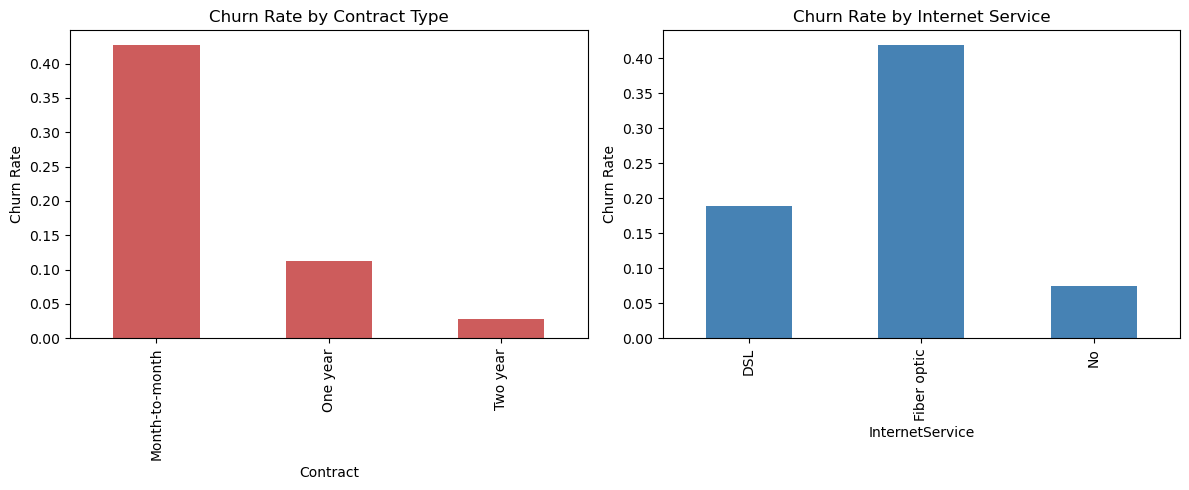

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes'].plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')

df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()['Yes'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Churn Rate by Internet Service')
axes[1].set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()